In [1]:
import warnings
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('default')

data_path = Path('/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v5/wgs.auto.par/results/16_cov_pheno_prep')

# 1) sex + pc (pc from BBJ projection)
cov_bbj_sex_pc = pd.read_csv(data_path / 'popgmm_subset_on_bbj_pcs.cov.sex.tsv', sep='\t')

# 2) sex + pc (pc from our genotype)
cov_genotype_sex_pc = pd.read_csv(data_path / 'popgmm_relatedness_aware_projection.cov.sex.tsv', sep='\t')

# 3) sex + age + pc (pc from BBJ projection)
cov_bbj_sex_age_pc = pd.read_csv(data_path / 'popgmm_subset_on_bbj_pcs.cov.sex_age_agez.tsv', sep='\t')

# 4) sex + age + pc (pc from our genotype)
cov_genotype_sex_age_pc = pd.read_csv(data_path / 'popgmm_relatedness_aware_projection.cov.sex_age_agez.tsv', sep='\t')

# 5) phenotype
pheno = pd.read_csv(data_path / 'popgmm_subset_on_bbj_pcs.pheno.tsv', sep='\t')

In [2]:

# ── Constants & helper functions ──────────────────────────────────────────────
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

ID_COLS   = ['#FID', 'IID']
PHENO_COL = 'PHENO1'
SEX_COL   = 'SEX'
AGE_COL   = 'AGE_Z'
MAX_PC    = 20


def merge_cov_pheno(cov_df, pheno_df):
    """Inner-join covariate and phenotype tables on ID columns."""
    return cov_df.merge(pheno_df[ID_COLS + [PHENO_COL]], on=ID_COLS, how='inner')


def detect_and_encode_pheno(df, pheno_col):
    """Return binary 0/1 phenotype array (handles 1/2 coding and 0/1)."""
    y = df[pheno_col].values.copy()
    unique = set(y)
    if unique <= {1, 2}:
        y = (y == 2).astype(int)
    return y


def fit_model(df, feature_cols, null_cols=None):
    """Return McFadden pseudo-R² for logistic regression with given features.

    null_cols: covariates for the null model (default: sex-only baseline).
               R² measures improvement of feature_cols model *over* this baseline.
    """
    import numpy as _np

    if null_cols is None:
        null_cols = [SEX_COL]

    y      = detect_and_encode_pheno(df, PHENO_COL)
    X_full = df[feature_cols].values
    X_null = df[null_cols].values

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        clf_full = LogisticRegression(C=1e12, solver='lbfgs', max_iter=1000)
        clf_full.fit(X_full, y)
        p_full  = clf_full.predict_proba(X_full)
        ll_full = _np.sum(_np.log(_np.clip(
            p_full[_np.arange(len(y)), y], 1e-15, 1)))

        clf_null = LogisticRegression(C=1e12, solver='lbfgs', max_iter=1000)
        clf_null.fit(X_null, y)
        p_null  = clf_null.predict_proba(X_null)
        ll_null = _np.sum(_np.log(_np.clip(
            p_null[_np.arange(len(y)), y], 1e-15, 1)))

    return 1.0 - ll_full / ll_null


def get_pc_cols(df):
    """Return PC columns (start with 'PC', end with '_AVG'), sorted numerically."""
    cols = [c for c in df.columns if c.startswith('PC') and c.endswith('_AVG')]
    return sorted(cols, key=lambda c: int(c[2:].replace('_AVG', '')))


def build_curve(df, base_cov, max_pc, null_cols=None):
    """
    For k = 0 .. max_pc, fit model with base_cov + first-k PCs against a
    sex-only null model (or the supplied null_cols).
    Returns DataFrame with columns: k_included, r2, step_gain.
    """
    import pandas as _pd
    if null_cols is None:
        null_cols = [SEX_COL]
    pc_cols = get_pc_cols(df)[:max_pc]
    rows = []
    prev_r2 = None
    for k in range(0, max_pc + 1):
        features = base_cov + pc_cols[:k]
        r2 = fit_model(df, features, null_cols=null_cols)
        step = (r2 - prev_r2) if prev_r2 is not None else float('nan')
        rows.append({'k_included': k, 'r2': r2, 'step_gain': step})
        prev_r2 = r2
    return _pd.DataFrame(rows)


# ── Merge dataframes ──────────────────────────────────────────────────────────
merged_bbj_sex_df      = merge_cov_pheno(cov_bbj_sex_pc,      pheno)
merged_genotype_sex_df = merge_cov_pheno(cov_genotype_sex_pc,  pheno)
merged_bbj_age_df      = merge_cov_pheno(cov_bbj_sex_age_pc,   pheno)
merged_genotype_age_df = merge_cov_pheno(cov_genotype_sex_age_pc, pheno)

# ── settings dict ─────────────────────────────────────────────────────────────
settings = {
    'no_age': {
        'base_cov': [SEX_COL],
        'data_map': {
            'bbj':      merged_bbj_sex_df,
            'genotype': merged_genotype_sex_df,
        },
    },
    'with_age': {
        'base_cov': [SEX_COL, AGE_COL],
        'data_map': {
            'bbj':      merged_bbj_age_df,
            'genotype': merged_genotype_age_df,
        },
    },
}

print("settings ready — merged shapes:")
for _tag, _cfg in settings.items():
    for _src, _df in _cfg['data_map'].items():
        print(f"  {_tag}/{_src}: {_df.shape}")


settings ready — merged shapes:
  no_age/bbj: (3050, 24)
  no_age/genotype: (3050, 24)
  with_age/bbj: (3049, 26)
  with_age/genotype: (3049, 26)


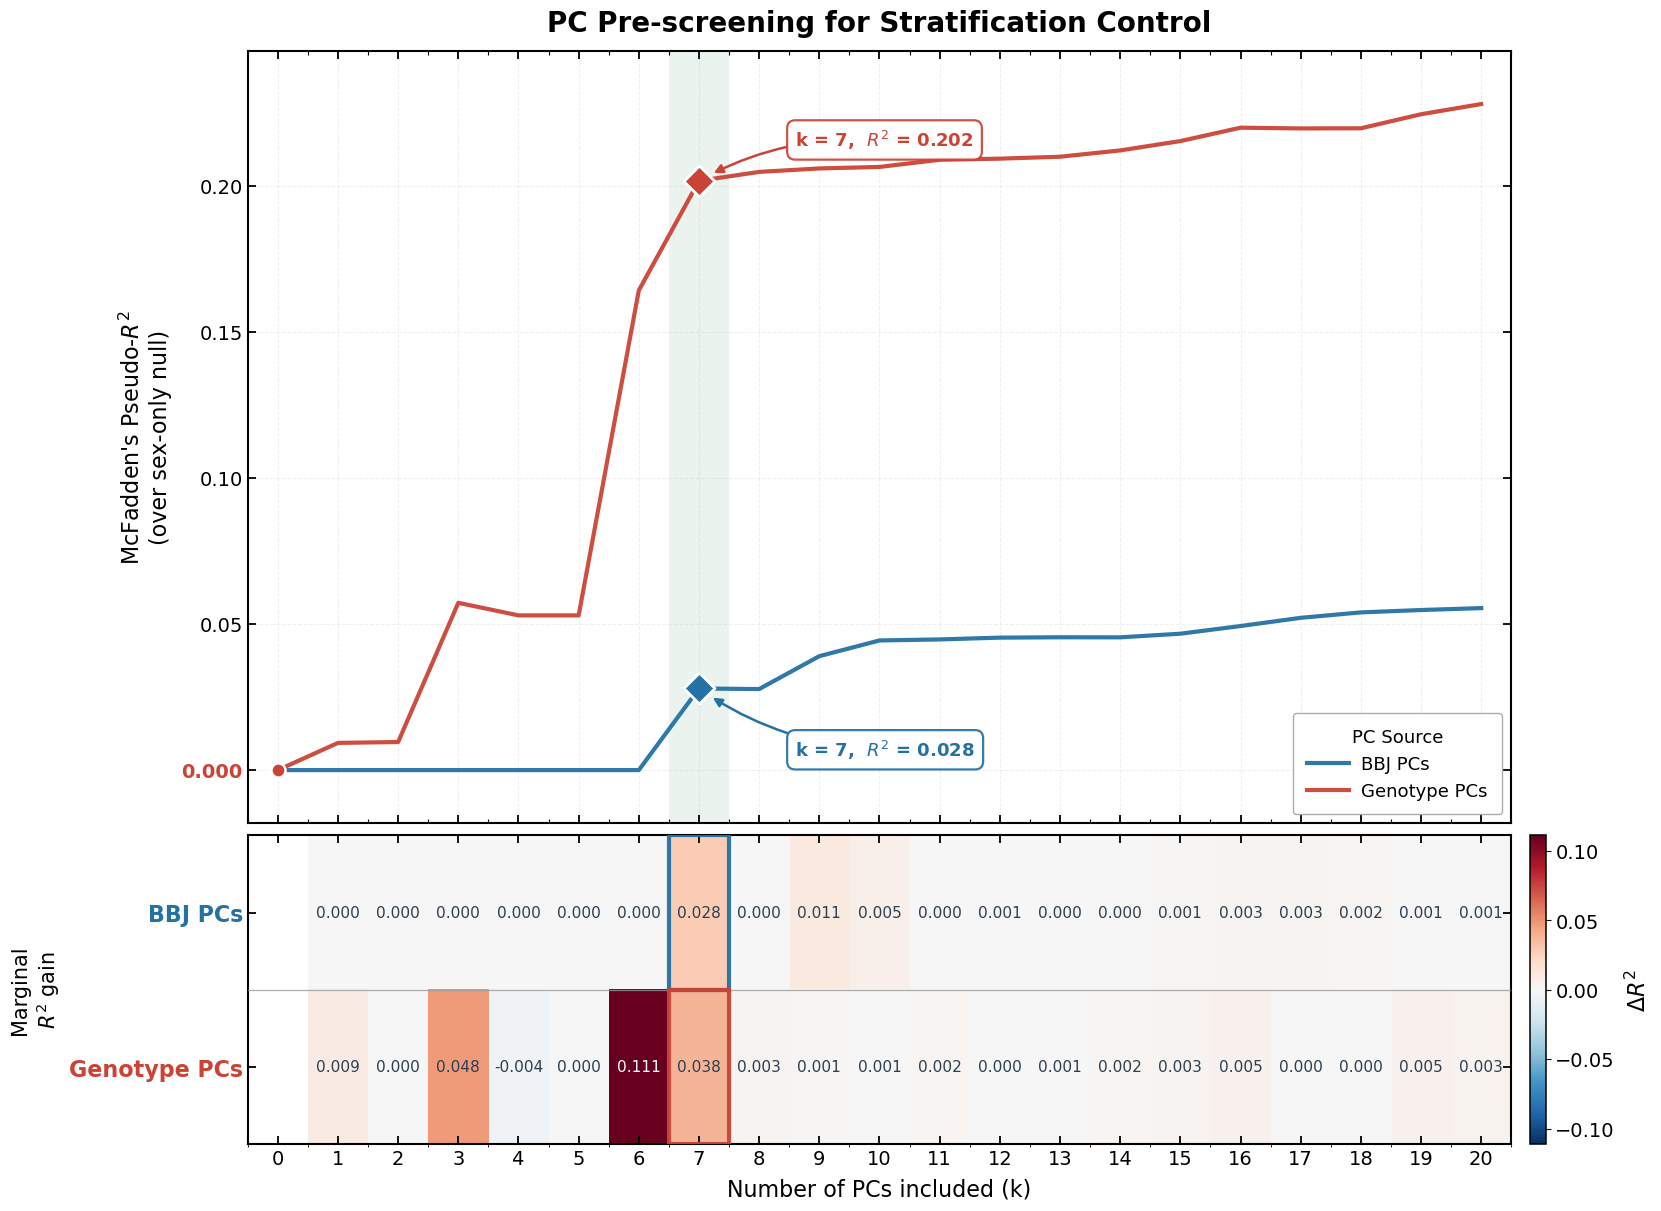

In [3]:

# ── Sex-adjusted only: BBJ vs Genotype PCs  ──────────────────────────────────
# Depends on: settings, build_curve, MAX_PC (defined in cell 2)
#
# Panel A: Absolute McFadden Pseudo-R²  — cumulative fit as PCs are added
# Panel B: Marginal gain heatmap         — per-PC contribution (BBJ vs Genotype)
# sharex=True: vertical alignment enables direct cross-panel reading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import AutoMinorLocator

# ── Decision parameters — update here to change chosen k per PC source ────────
CHOSEN_K = {'bbj': 7, 'genotype': 7}

_cfg_sex = settings['no_age']
_curves_sex = {
    src: build_curve(df, _cfg_sex['base_cov'], MAX_PC)
    for src, df in _cfg_sex['data_map'].items()
}

_C2    = {'bbj': '#2471A3', 'genotype': '#CB4335'}
_PL2   = {'bbj': 'BBJ PCs', 'genotype': 'Genotype PCs'}
_GREEN = '#1A7A3C'

# ── Publication-quality typography ────────────────────────────────────────────
_FS = {'title': 20, 'label': 16, 'tick': 14, 'legend': 13, 'annot': 13, 'heat': 11}
plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'font.size':       _FS['tick'],
    'axes.titlesize':  _FS['title'],
    'axes.labelsize':  _FS['label'],
    'xtick.labelsize': _FS['tick'],
    'ytick.labelsize': _FS['tick'],
    'legend.fontsize': _FS['legend'],
    'axes.linewidth':  1.5,
})

fig, (ax1, ax3) = plt.subplots(
    2, 1,
    figsize=(16.5, 12.0),
    gridspec_kw={'height_ratios': [2.5, 1]},
    sharex=True,
    constrained_layout=True,
)

# ── Panel A: Absolute Pseudo-R² ───────────────────────────────────────────────
_unique_ks = sorted(set(CHOSEN_K.values()))
if len(_unique_ks) == 1:
    ax1.axvspan(_unique_ks[0] - 0.5, _unique_ks[0] + 0.5,
                color=_GREEN, alpha=0.09, zorder=-1, lw=0)
else:
    for _src, _k in CHOSEN_K.items():
        ax1.axvspan(_k - 0.5, _k + 0.5,
                    color=_C2[_src], alpha=0.08, zorder=-1, lw=0)

_r0_vals, _rk_vals = {}, {}
for _src, _curve in _curves_sex.items():
    _g = _curve.sort_values('k_included')
    ax1.plot(_g['k_included'], _g['r2'],
             color=_C2[_src], linewidth=3.0, alpha=0.95, label=_PL2[_src])
    _r0_vals[_src] = float(_g.loc[_g['k_included'] == 0, 'r2'].iloc[0])
    _rk_vals[_src] = float(_g.loc[_g['k_included'] == CHOSEN_K[_src], 'r2'].iloc[0])
    ax1.scatter(0, _r0_vals[_src], color=_C2[_src], s=100, zorder=5,
                edgecolors='white', linewidths=1.6)

_ann_cfg = {
    'bbj':      {'dy': -0.021, 'rad': -0.15},
    'genotype': {'dy': +0.014, 'rad': +0.15},
}
for _src in ['bbj', 'genotype']:
    _xk = CHOSEN_K[_src]
    _yk = _rk_vals[_src]
    ax1.scatter(_xk, _yk, color=_C2[_src], s=250,
                marker='D', zorder=7, edgecolors='white', linewidths=2.0)
    ax1.annotate(
        f'k = {_xk},  $R^2$ = {_yk:.3f}',
        xy=(_xk, _yk),
        xytext=(_xk + 1.6, _yk + _ann_cfg[_src]['dy']),
        fontsize=_FS['annot'], color=_C2[_src], fontweight='bold',
        ha='left', va='center',
        bbox=dict(boxstyle='round,pad=0.45', facecolor='white', alpha=0.92,
                  edgecolor=_C2[_src], linewidth=1.6),
        arrowprops=dict(arrowstyle='-|>', color=_C2[_src], lw=1.8,
                        connectionstyle=f'arc3,rad={_ann_cfg[_src]["rad"]}',
                        shrinkA=0, shrinkB=12),
        zorder=10,
    )

_all_r2 = [v for _src in ['bbj', 'genotype'] for v in _curves_sex[_src]['r2'].tolist()]
_y_lo, _y_hi = min(_all_r2), max(_all_r2)
_ypad = (_y_hi - _y_lo) * 0.08
ax1.set_ylim(_y_lo - _ypad, _y_hi + _ypad)

_ylim = ax1.get_ylim()
_auto_ticks  = sorted({t for t in ax1.get_yticks() if _ylim[0] <= t <= _ylim[1]})
_auto_clean  = [t for t in _auto_ticks
                if not any(abs(t - _r0_vals[s]) < 0.005 for s in ['bbj', 'genotype'])]
_all_ticks   = sorted(set(_auto_clean) | {round(_r0_vals[s], 8) for s in ['bbj', 'genotype']})
_tick_labels = [
    f'{t:.3f}' if any(abs(t - _r0_vals[s]) < 1e-6 for s in ['bbj', 'genotype'])
    else f'{t:.2f}'
    for t in _all_ticks
]
ax1.set_yticks(_all_ticks)
ax1.set_yticklabels(_tick_labels, fontsize=_FS['tick'])
for _lbl, _t in zip(ax1.get_yticklabels(), _all_ticks):
    for _src in ['bbj', 'genotype']:
        if abs(_t - _r0_vals[_src]) < 1e-6:
            _lbl.set_color(_C2[_src])
            _lbl.set_fontweight('bold')

ax1.set_title("PC Pre-screening for Stratification Control", pad=14, fontweight='bold')
ax1.set_ylabel("McFadden's Pseudo-$R^2$\n(over sex-only null)", labelpad=7)
ax1.set_axisbelow(True)
ax1.grid(alpha=0.18, linewidth=0.75, linestyle='--')
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
ax1.legend(loc='lower right', framealpha=0.97, edgecolor='#aaaaaa',
           borderpad=0.8, handlelength=2.3, handletextpad=0.7,
           title='PC Source', title_fontsize=_FS['legend'])
ax1.tick_params(direction='in', length=5.5, width=1.3, top=True, right=True, which='major')
ax1.tick_params(direction='in', length=3.0, width=0.8, top=True, right=True, which='minor')

# ── Panel B: Marginal step gain heatmap (diverging — supports negative gain) ──
_src_order = ['bbj', 'genotype']
_row_map   = {s: i for i, s in enumerate(_src_order)}

_mat2, _rl2 = [], []
for _src in _src_order:
    # No clip: keep raw step_gain including negative values (numerical noise)
    _step = (
        _curves_sex[_src].set_index('k_included')['step_gain']
        .reindex(range(1, MAX_PC + 1)).fillna(0).values
    )
    _mat2.append(_step)
    _rl2.append(_PL2[_src])
_mat2 = np.array(_mat2)

# Symmetric color scale centered at 0
_vabs = float(np.nanmax(np.abs(_mat2)))
_im2 = ax3.imshow(
    _mat2, aspect='auto', cmap='RdBu_r', interpolation='nearest',
    vmin=-_vabs, vmax=_vabs,
    extent=[0.5, MAX_PC + 0.5, 1.5, -0.5],
)

# Zero-reference line on colorbar: white = 0 (center of RdBu_r)
for _ri in range(_mat2.shape[0]):
    for _ci in range(_mat2.shape[1]):
        _v = _mat2[_ri, _ci]
        # Use dark text near zero (white region), white text on strong red/blue
        _txt_col = 'white' if abs(_v) > 0.45 * _vabs else '#2C3E50'
        _v_disp = np.round(_v, 3)
        if _v_disp == 0:
            _v_disp = 0.0
        _fmt = f'{_v_disp:+.3f}' if _v_disp < 0 else f'{_v_disp:.3f}'
        ax3.text(_ci + 1, _ri, _fmt,
                 ha='center', va='center', fontsize=_FS['heat'], color=_txt_col, zorder=4)

# Row separator
ax3.axhline(0.5, color='#999999', linewidth=0.9, zorder=3, alpha=0.8)

# Per-row decision highlight
for _src, _ri in _row_map.items():
    _k = CHOSEN_K[_src]
    ax3.add_patch(mpatches.FancyBboxPatch(
        (_k - 0.5, _ri - 0.5), 1.0, 1.0,
        boxstyle='square,pad=0',
        linewidth=3.0, edgecolor=_C2[_src], facecolor='none', zorder=5, alpha=0.95,
    ))

ax3.set_xlabel('Number of PCs included (k)', labelpad=7)
ax3.set_ylabel('Marginal\n$R^2$ gain', labelpad=5, fontsize=_FS['label'] - 1)
ax3.set_yticks([0, 1])
_ytl = ax3.set_yticklabels(_rl2, fontsize=_FS['label'])
_ytl[0].set_color(_C2['bbj'])
_ytl[0].set_fontweight('bold')
_ytl[1].set_color(_C2['genotype'])
_ytl[1].set_fontweight('bold')
ax3.tick_params(direction='in', length=5.5, width=1.3, top=True, right=True)
ax3.set_xlim(-0.5, MAX_PC + 0.5)
ax3.set_xticks(np.arange(0, MAX_PC + 1, 1))

_cbar2 = plt.colorbar(_im2, ax=ax3, fraction=0.022, pad=0.015)
_cbar2.set_label(r"$\Delta R^2$", rotation=90, labelpad=8, fontsize=_FS['label'])
_cbar2.ax.axhline(0.5, color='black', linewidth=1.0, alpha=0.5)  # zero marker on colorbar
_cbar2.outline.set_linewidth(1.1)
_cbar2.ax.tick_params(labelsize=_FS['tick'])

plt.show()
# fig.savefig('pc_selection_summary.pdf', dpi=300, bbox_inches='tight')


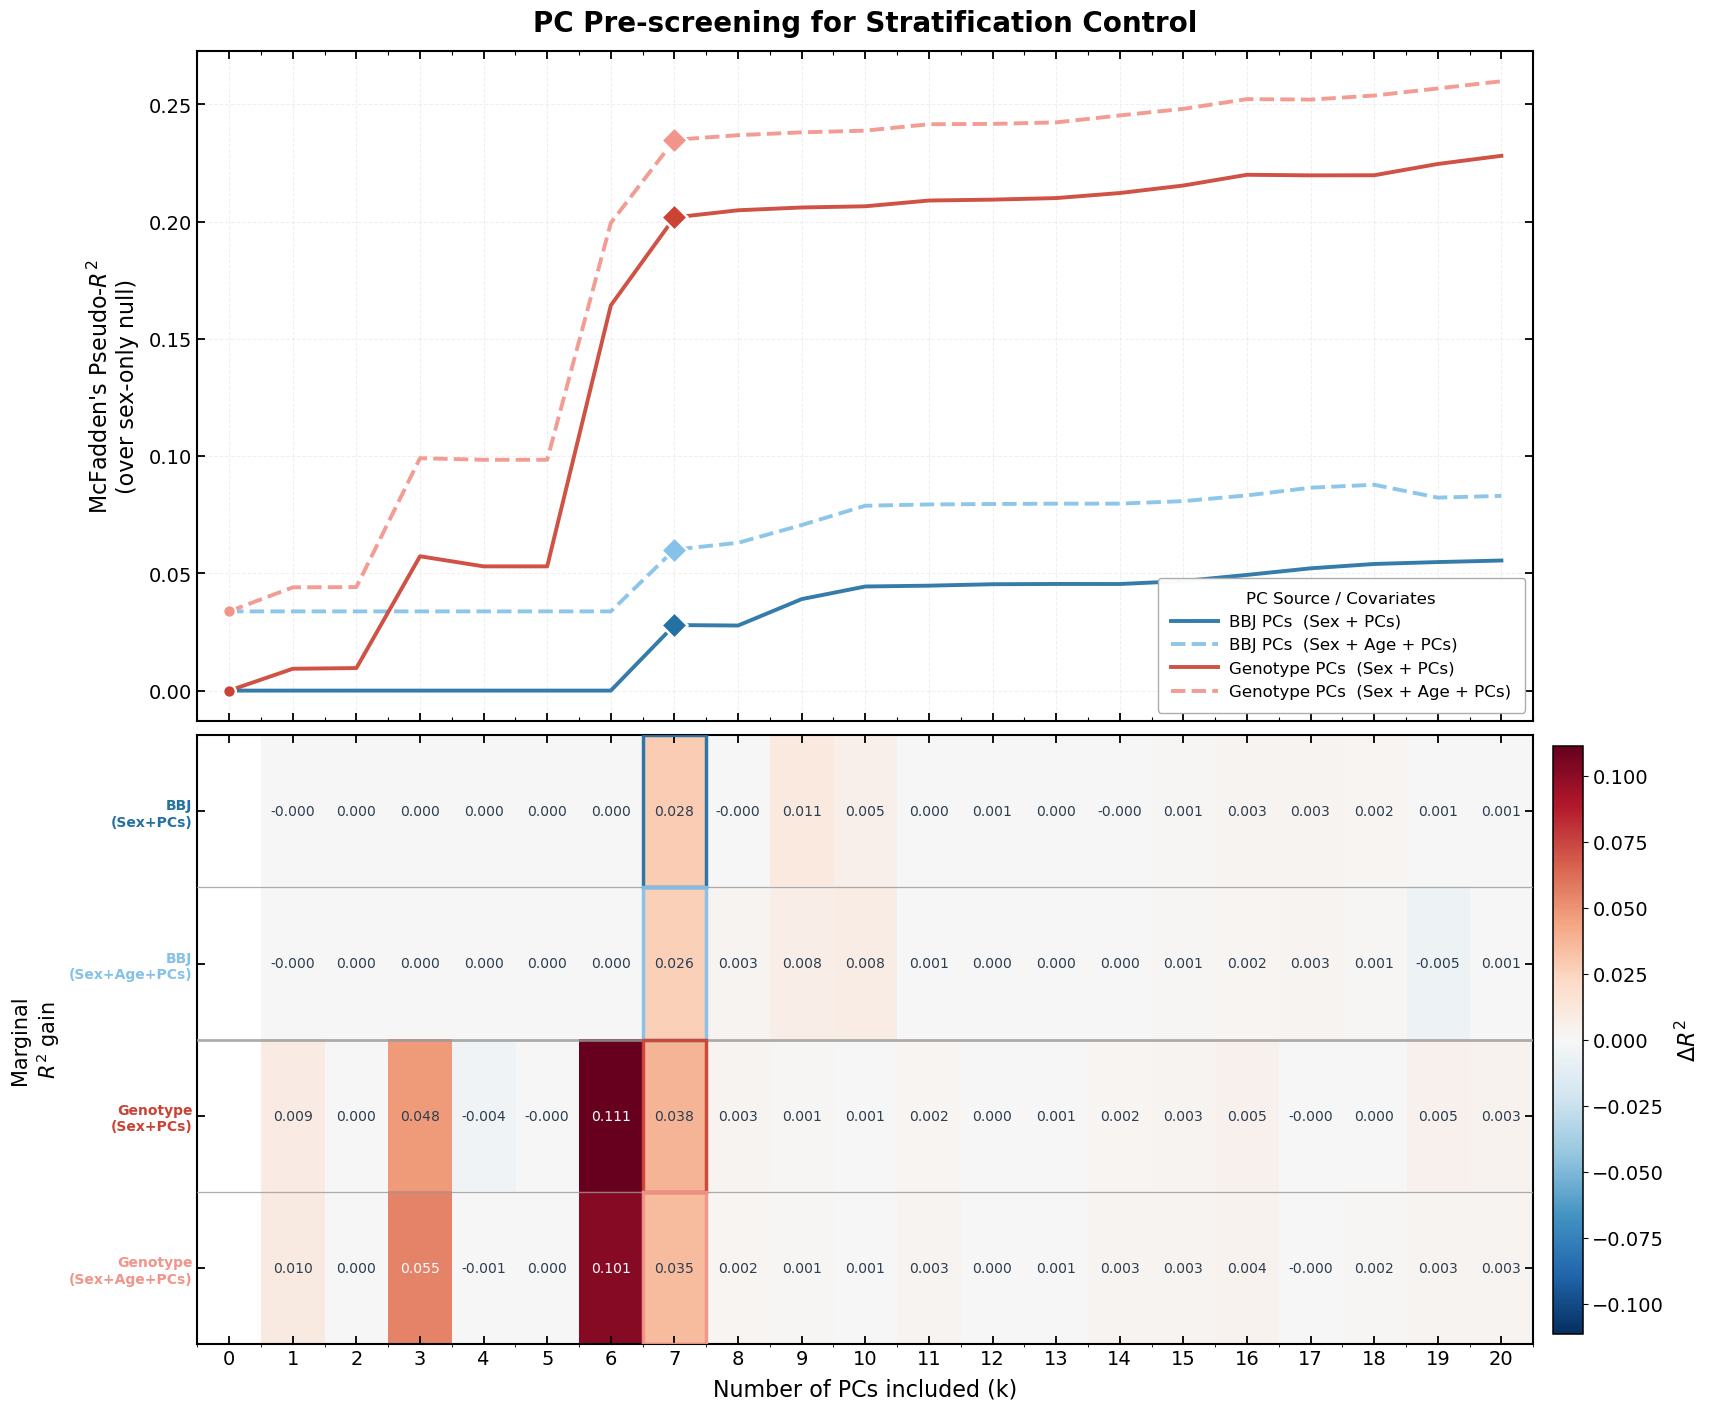

In [4]:

# ── Combined comparison: Sex-only null — PCs only vs PCs + Age  ───────────────
# Null model = sex-only for all four curves.
# Lines:
#   BBJ PCs            (full = sex + k PCs)
#   BBJ PCs + Age      (full = sex + age + k PCs)
#   Genotype PCs       (full = sex + k PCs)
#   Genotype PCs + Age (full = sex + age + k PCs)
# Panel A: Cumulative Pseudo-R² (gain over sex-only null)
# Panel B: Marginal gain heatmap (4 rows)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import AutoMinorLocator

# ── Decision parameters ───────────────────────────────────────────────────────
CHOSEN_K_C4 = {
    'bbj_no_age':      7,
    'bbj_age':         7,
    'genotype_no_age': 7,
    'genotype_age':    7,
}

# ── Build curves — all vs sex-only null ───────────────────────────────────────
_curves_c4 = {
    'bbj_no_age':      build_curve(merged_bbj_sex_df,      [SEX_COL],          MAX_PC, null_cols=[SEX_COL]),
    'bbj_age':         build_curve(merged_bbj_age_df,       [SEX_COL, AGE_COL], MAX_PC, null_cols=[SEX_COL]),
    'genotype_no_age': build_curve(merged_genotype_sex_df,  [SEX_COL],          MAX_PC, null_cols=[SEX_COL]),
    'genotype_age':    build_curve(merged_genotype_age_df,  [SEX_COL, AGE_COL], MAX_PC, null_cols=[SEX_COL]),
}

_ROW_ORDER = ['bbj_no_age', 'bbj_age', 'genotype_no_age', 'genotype_age']

_COLORS = {
    'bbj_no_age':      '#2471A3',
    'bbj_age':         '#85C1E9',
    'genotype_no_age': '#CB4335',
    'genotype_age':    '#F1948A',
}
_LSTYLE = {
    'bbj_no_age':      '-',
    'bbj_age':         '--',
    'genotype_no_age': '-',
    'genotype_age':    '--',
}
_LABELS = {
    'bbj_no_age':      'BBJ PCs  (Sex + PCs)',
    'bbj_age':         'BBJ PCs  (Sex + Age + PCs)',
    'genotype_no_age': 'Genotype PCs  (Sex + PCs)',
    'genotype_age':    'Genotype PCs  (Sex + Age + PCs)',
}
_HEAT_LABELS = {
    'bbj_no_age':      'BBJ\n(Sex+PCs)',
    'bbj_age':         'BBJ\n(Sex+Age+PCs)',
    'genotype_no_age': 'Genotype\n(Sex+PCs)',
    'genotype_age':    'Genotype\n(Sex+Age+PCs)',
}

_FS = {'title': 20, 'label': 16, 'tick': 14, 'legend': 12, 'annot': 12, 'heat': 10}
plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'font.size':       _FS['tick'],
    'axes.titlesize':  _FS['title'],
    'axes.labelsize':  _FS['label'],
    'xtick.labelsize': _FS['tick'],
    'ytick.labelsize': _FS['tick'],
    'legend.fontsize': _FS['legend'],
    'axes.linewidth':  1.5,
})

fig4, (ax1, ax3) = plt.subplots(
    2, 1,
    figsize=(17.0, 14.0),
    gridspec_kw={'height_ratios': [2.2, 2.0]},
    sharex=True,
    constrained_layout=True,
)

# ── Panel A: Cumulative R² ────────────────────────────────────────────────────
_r0_vals = {}
for _key in _ROW_ORDER:
    _g = _curves_c4[_key].sort_values('k_included')
    ax1.plot(_g['k_included'], _g['r2'],
             color=_COLORS[_key], linestyle=_LSTYLE[_key],
             linewidth=2.8, alpha=0.92, label=_LABELS[_key])
    _r0 = float(_g.loc[_g['k_included'] == 0, 'r2'].iloc[0])
    _r0_vals[_key] = _r0
    ax1.scatter(0, _r0, color=_COLORS[_key], s=80, zorder=5,
                edgecolors='white', linewidths=1.5)
    # Mark chosen k
    _rk = float(_g.loc[_g['k_included'] == CHOSEN_K_C4[_key], 'r2'].iloc[0])
    ax1.scatter(CHOSEN_K_C4[_key], _rk, color=_COLORS[_key],
                s=180, marker='D', zorder=7, edgecolors='white', linewidths=1.8)

ax1.set_title(
    "PC Pre-screening for Stratification Control",
    pad=14, fontweight='bold',
)
ax1.set_ylabel("McFadden's Pseudo-$R^2$\n(over sex-only null)", labelpad=7)
ax1.set_axisbelow(True)
ax1.grid(alpha=0.18, linewidth=0.75, linestyle='--')
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
ax1.legend(loc='lower right', framealpha=0.97, edgecolor='#aaaaaa',
           borderpad=0.8, handlelength=2.8, handletextpad=0.7,
           title='PC Source / Covariates', title_fontsize=_FS['legend'])
ax1.tick_params(direction='in', length=5.5, width=1.3, top=True, right=True, which='major')
ax1.tick_params(direction='in', length=3.0, width=0.8, top=True, right=True, which='minor')

# ── Panel B: Marginal gain heatmap (4 rows) ───────────────────────────────────
_mat4, _rl4 = [], []
for _key in _ROW_ORDER:
    _step = (
        _curves_c4[_key].set_index('k_included')['step_gain']
        .reindex(range(1, MAX_PC + 1)).fillna(0).values
    )
    _mat4.append(_step)
    _rl4.append(_HEAT_LABELS[_key])
_mat4 = np.array(_mat4)

_vabs = float(np.nanmax(np.abs(_mat4)))
_im4 = ax3.imshow(
    _mat4, aspect='auto', cmap='RdBu_r', interpolation='nearest',
    vmin=-_vabs, vmax=_vabs,
    extent=[0.5, MAX_PC + 0.5, len(_ROW_ORDER) - 0.5, -0.5],
)

for _ri in range(_mat4.shape[0]):
    for _ci in range(_mat4.shape[1]):
        _v = _mat4[_ri, _ci]
        _txt_col = 'white' if abs(_v) > 0.45 * _vabs else '#2C3E50'
        _v_disp = np.round(_v, 3)
        _fmt = f'{_v_disp:+.3f}' if _v_disp < 0 else f'{_v_disp:.3f}'
        ax3.text(_ci + 1, _ri, _fmt,
                 ha='center', va='center', fontsize=_FS['heat'], color=_txt_col, zorder=4)

# Row separators between groups
for _i in range(1, len(_ROW_ORDER)):
    _lw = 2.0 if _i == 2 else 0.9  # thicker line between BBJ and Genotype groups
    ax3.axhline(_i - 0.5, color='#999999', linewidth=_lw, zorder=3, alpha=0.8)

# Highlight chosen k per row
for _ri, _key in enumerate(_ROW_ORDER):
    _k = CHOSEN_K_C4[_key]
    ax3.add_patch(mpatches.FancyBboxPatch(
        (_k - 0.5, _ri - 0.5), 1.0, 1.0,
        boxstyle='square,pad=0',
        linewidth=2.5, edgecolor=_COLORS[_key], facecolor='none', zorder=5, alpha=0.95,
    ))

ax3.set_xlabel('Number of PCs included (k)', labelpad=7)
ax3.set_ylabel('Marginal\n$R^2$ gain', labelpad=5, fontsize=_FS['label'] - 1)
ax3.set_yticks(range(len(_ROW_ORDER)))
_ytl = ax3.set_yticklabels(_rl4, fontsize=10)
for _i, _key in enumerate(_ROW_ORDER):
    _ytl[_i].set_color(_COLORS[_key])
    _ytl[_i].set_fontweight('bold')
ax3.tick_params(direction='in', length=5.5, width=1.3, top=True, right=True)
ax3.set_xlim(-0.5, MAX_PC + 0.5)
ax3.set_xticks(np.arange(0, MAX_PC + 1, 1))

_cbar4 = plt.colorbar(_im4, ax=ax3, fraction=0.022, pad=0.015)
_cbar4.set_label(r"$\Delta R^2$", rotation=90, labelpad=8, fontsize=_FS['label'])
_cbar4.ax.axhline(0.5, color='black', linewidth=1.0, alpha=0.5)
_cbar4.outline.set_linewidth(1.1)
_cbar4.ax.tick_params(labelsize=_FS['tick'])

plt.show()
# fig4.savefig('pc_selection_combined.pdf', dpi=300, bbox_inches='tight')
